# Header: Sensitivity gradient for surveys of the HT-ATES site (version 1)

**Research setting:** hot water is injected into a shallow aquifer at the HT-ATES site in Delft. We investigate the use of a surface-to-borehole CSEM monitoring set-up for recovering the shape of the hot plume that develops.

**Based on:** The EASYGO summer school exercises: https://github.com/emsig/easygo-training-em/blob/main/emg3d_ATES.ipynb

## Version 2: Comparing computed sensitivity gradient with an FD computation and an empymod computation

We work with a layered model so that empymod can be used to find similar insights.

We compute the gradient for a single source-receiver combination and compare between the adjoint method and finite difference method.

We then work with empymod and produce the gradient using layered=True and using the finite difference method

**A coarse grid is used for ease of computation**

# Code

In [1]:
import emg3d
import empymod
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize
from Emg3d_extra_grid_functions import *

plt.style.use('bmh')

# Comment this out on Google Colab
#%matplotlib widget

## Functions

In [ ]:
#define interpolation functions
def find_distance2d(coord1, coord2):
    distance = (coord1[0]-coord2[0])**2+(coord1[1]-coord2[1])**2
    return distance
    #This is the distance squared but it should work the same

def interpolate2d(location, array):
    dis = []
    for i in np.arange(len(array)):
        dis.append(find_distance2d(location, array[i]))
    return np.argmin(dis)

### Selecting cuboids from the grid

In [ ]:
def point2index_xyz(grid, point, QC=False):
    #Assumes that 
    
    x_spacing = min(grid.h[0])
    y_spacing = min(grid.h[1])
    z_spacing = min(grid.h[2])

    grid_center_i = int((grid.n_cells+grid.shape_cells[0]*grid.shape_cells[1]+ grid.shape_cells[0])/2)
    grid_center =  grid.cell_centers[grid_center_i]

    ix_steps = int((point[0]-grid_center[0])/x_spacing)
    iy_steps = int((point[1]-grid_center[1])/y_spacing)
    iz_steps = int((point[2]-grid_center[2])/z_spacing)
    
    ix = int(grid.shape_cells[0]/2)+ix_steps
    iy = int(grid.shape_cells[1]/2)+iy_steps
    iz = int(grid.shape_cells[2]/2)+iz_steps

    if grid.h[0][int(grid.shape_cells[0]/2)] != x_spacing:
        print('Warning: no homogeneous x-spacing')
    if grid.h[1][int(grid.shape_cells[1]/2)] != y_spacing:
        print('Warning: no homogeneous y-spacing')
    if grid.h[2][int(grid.shape_cells[2]/2)] != z_spacing:
        print('Warning: no homogeneous z-spacing')

    if QC==True:
        print('x: ', grid.cell_centers_x[ix])
        print('y: ', grid.cell_centers_y[iy])
        print('z: ', grid.cell_centers_z[iz])

    return ix, iy, iz

In [ ]:
def find_cuboid_indeces_xyz(grid, x_extent, y_extent, zmin, zmax, QC=True):

    cornerpoint1 = [-x_extent, -y_extent, zmin]
    cornerpoint2 = [x_extent, y_extent, zmax]

    if QC==True:
        print(cornerpoint1, cornerpoint2)
    
    ix_min, iy_min, iz_min = point2index_xyz(grid, cornerpoint1, QC=False)
    ix_max, iy_max, iz_max = point2index_xyz(grid, cornerpoint2, QC=False)

    return ix_min, iy_min, iz_min, ix_max, iy_max, iz_max

In [ ]:
def change_cuboid_resistivity(res_orig, grid, x_extent, y_extent, zmin, zmax, target_res):
    #Assumes that cuboid will be created around x=0 and y=0
    #Only works for grids that are symmetric around the origin in the number of cells

    ix_min, iy_min, iz_min, ix_max, iy_max, iz_max = find_cuboid_indeces_xyz(grid, x_extent, y_extent, zmin, zmax)

    #QC the bounds
    print('x bounds: ', grid.cell_centers_x[ix_min], ' , ', grid.cell_centers_x[ix_max])
    print('y_bounds: ', grid.cell_centers_y[iy_min], ' , ', grid.cell_centers_y[iy_max])
    print('z_bounds: ', grid.cell_centers_z[iz_min], ' , ', grid.cell_centers_z[iz_max])

    # Set target resistivity of the cuboid
    res_new = res_orig
    res_new[ix_min:ix_max, iy_min:iy_max, iz_min:iz_max] = target_res

    return res_new

### Manual plotting of values (vs. plot_slice)
This is done to enable comparison with empymod

To compare with empymod, we crop the field values to the inner domain by finding the boundary indeces.
Note: we can only use the inner domain where no cell stretching is taking place: y = [-300, 300], z = [-250, -5] & cell width is constant

Note about plotting:

When using plot_slice, the simulation output is interpolated to the cell centers, which results in a slightly different plot than when the output is directly plotted using matplotlib. Especially beneath the source this is visible, as the field value should be 0 there but this is not shown if the field value is not sampled (or interpolated) to that exact point.

I have chosen here to use the matplotlib plotting, and to accept the inaccuracy below the source, as this makes it easier to compare results between emg3d and empymod

In [ ]:
def crop_to_domain(efield3D, grid, x_slice = 0, y_extent=300, zmin=-250, zmax=0):

    #This method assumes cell_centers are the relevant parameters
    ix_min, iy_min, iz_min, ix_max, iy_max, iz_max = find_cuboid_indeces_xyz(grid, x_slice, y_extent, zmin, zmax, QC=True)

    #QC the bounds
    print('x position: ', grid.nodes_x[ix_max])
    print('y_bounds: ', grid.nodes_y[iy_min], ' , ', grid.nodes_y[iy_max+1])
    print('z_bounds: ', grid.cell_centers_z[iz_min], ' , ', grid.cell_centers_z[iz_max])

    # Crop Ez field array
    crop_efield3D = efield3D.fz[ix_max, iy_min:iy_max+2, iz_min:iz_max+1]
    crop_efield3D = np.flip(np.transpose(crop_efield3D), axis=0)

    return crop_efield3D

In [ ]:
def manual_plot_slice(efield, grid, y_extent=300, zmin=-250, zmax=0, size_y = 6.4, size_z = 4.8, vmin = 1e-7, vmax = 1e-6, norm = 'log'):
    
    fig, ax = plt.subplots()
    plt.imshow(np.abs(efield), extent = [0, size_y, 0, size_z], norm=norm, vmin = vmin, vmax = vmax)
    ax.set_title('Field')
    #ax.set_xlabel('Offset (km)')
    #ax.set_ylabel('Depth (1e2 m)')
    plt.colorbar(location='right', fraction=0.035)
    plt.xticks(np.arange(0, size_y, size_y/4), np.arange(-y_extent, y_extent, y_extent/2))
    plt.yticks(np.arange(0, size_z, size_z/4), np.arange(zmin, zmax, (zmax-zmin)/4))
    plt.grid(False)
    plt.show()

In [ ]:
def manual_plot_slice_3x(efield1, efield2, efield3, y_extent=-300, zmin=-250, zmax=0, size_y = 6.4, size_z = 4.8, vmin = 1e-8, vmax = 1e-4):

    fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(15,5))

    ax1_plot = ax1.imshow(np.abs(efield1), extent = [0, size_y, 0, size_z], norm='log', vmin = vmin, vmax = vmax)
    ax1.set_title('Field 1 |Ez| (V/m)')
    ax1.set_xlabel('y (m)')
    ax1.set_ylabel('z (m)')
    plt.colorbar(ax1_plot, location='bottom')
    ax1.set_xticks(np.arange(0, size_y, size_y/4), np.arange(-y_extent, y_extent, y_extent/2))
    ax1.set_yticks(np.arange(0, size_z, size_z/4), np.arange(zmin, zmax, (zmax-zmin)/4))
    ax1.grid(False)
    
    ax2_plot = ax2.imshow(np.abs(efield2), extent = [0, size_y, 0, size_z], norm='log', vmin = vmin, vmax = vmax)
    ax2.set_title('Field 2 |Ez| (V/m)')
    ax2.set_xlabel('y (m)')
    ax2.set_ylabel('z (m)')
    plt.colorbar(ax2_plot, location='bottom')
    ax2.set_xticks(np.arange(0, size_y, size_y/4), np.arange(-y_extent, y_extent, y_extent/2))
    ax2.set_yticks(np.arange(0, size_z, size_z/4), np.arange(zmin, zmax, (zmax-zmin)/4))
    ax2.grid(False)
    
    ax3_plot = ax3.imshow(np.abs(efield3), extent = [0, size_y, 0, size_z], norm='log', vmin = vmin, vmax = vmax)
    ax3.set_title('Field 3 |Ez| (V/m)')
    ax3.set_xlabel('y (m)')
    ax3.set_ylabel('z (m)')
    plt.colorbar(ax3_plot, location='bottom')
    ax3.set_xticks(np.arange(0, size_y, size_y/4), np.arange(-y_extent, y_extent, y_extent/2))
    ax3.set_yticks(np.arange(0, size_z, size_z/4), np.arange(zmin, zmax, (zmax-zmin)/4))
    ax3.grid(False)

## Comparing adjoint and FD gradient for a single source-receiver pair

- The hot plume is centred at x=0, y=0
- Receiver is located at x=0, y=74
- Depth is negative!

In [15]:
# Create a survey

# Acquisition source frequencies (Hz)
frequencies = [1.0]

# Source coordinates, a y-directed source at 150 m distance from the receivers
src_x, src_y, src_z = 0, -75, 0
src = emg3d.surveys.txrx_coordinates_to_dict(emg3d.TxElectricDipole,(0, -75, 0, 90.0, 0.0))
colors = ['blue']

# Receiver positions, vertical z-directed point dipoles
rec_x, rec_y, rec_z = [0]*4, [75]*4, np.arange(1,5)*-50
rec = emg3d.surveys.txrx_coordinates_to_dict(emg3d.RxElectricPoint, (np.array([0]*4), np.array([75]*4), np.arange(1,5)*-50, 0.0, 90.0))

In [16]:
survey = emg3d.surveys.Survey(
    name='Example survey, not used',  # Name of the survey
    sources=src,               # Source coordinates
    receivers=rec,             # Receiver coordinates
    frequencies=frequencies,   # Two frequencies
    # data=data,               # If you have observed data
    noise_floor=1e-15,
    relative_error=0.01,
)

# Let's have a look at the survey:
survey

:: Survey «Example survey, not used» ::

<xarray.Dataset> Size: 196B
Dimensions:   (src: 1, rec: 4, freq: 1)
Coordinates:
  * src       (src) <U6 24B 'TxED-1'
  * rec       (rec) <U6 96B 'RxEP-1' 'RxEP-2' 'RxEP-3' 'RxEP-4'
  * freq      (freq) <U3 12B 'f-1'
Data variables:
    observed  (src, rec, freq) complex128 64B (nan+nanj) ... (nan+nanj)
Attributes:
    noise_floor:     1e-15
    relative_error:  0.01

In [17]:
grid = emg3d.construct_mesh(
    center=(0,0,0),                                 # Center of wanted grid
    frequency=frequencies[0],                            # Frequency we will use the grid for
    properties=[25, 1e8],                       # Reference resistivity
    domain=([-50, 50], [-100, 100], [-250, 0]),   # Domain in which we want precise results
    center_on_edge=True,
    min_width_limits = [20, 20, 10],
)
 
grid  # mesh info
#grid.plot_grid() # plotting the grid

TensorMesh: 184,320 cells

                      MESH EXTENT             CELL WIDTH      FACTOR
  dir    nC        min           max         min       max      max
  ---   ---  ---------------------------  ------------------  ------
   x     48   -105,557.77    105,557.77     20.00 31,181.26    1.42
   y     48   -105,724.98    105,724.98     20.00 34,267.01    1.48
   z     80   -103,688.81    103,448.81     10.00 26,162.45    1.34

### Models to use

In [18]:
#Uniform resistivity model with only air interface included and 33 Ohmm resistivity everywhere (average of Bortollotti values)
depth = [0]

# Layer resistivities in Ohm.m
resistivities_unif = np.array([1e8, 33.0]) # base incl. air (lower res, because of 3D modelling)

# Pre-allocate an array with number of cells corresponding to our grid
res = np.ones(grid.shape_cells)

# Layered base model: Fill in layered resistivities into our grid
dd = np.r_[np.inf, depth, -np.inf]
for i in range(len(resistivities_unif)):
    res[:, :, (grid.cell_centers_z > dd[i+1]) & (grid.cell_centers_z <= dd[i])] = resistivities_unif[i]

# Create the homogenous 25 kOhm model
model_unif = emg3d.Model(grid, property_x=res, mapping='Resistivity')

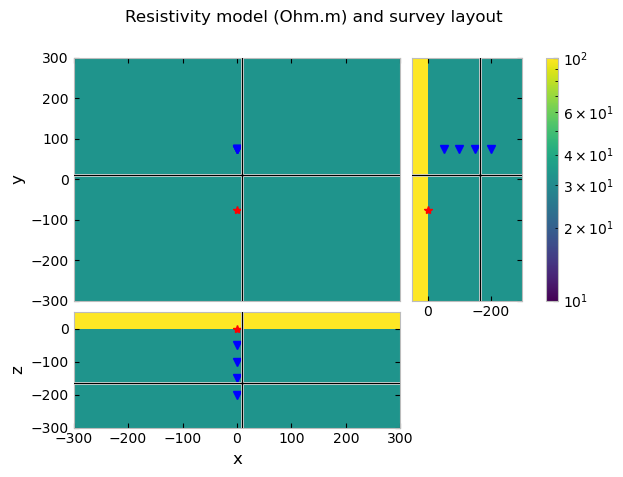

In [19]:
# Plot/QC the model
grid.plot_3d_slicer(
    model_unif.property_x,
    pcolor_opts={'norm': LogNorm(vmin=10, vmax=100)},
    xlim=[-300, 300],
    ylim=[-300, 300],
    zlim=[-300, 50],
    zslice=-160,
)
# Plot survey in figure above
fig = plt.gcf()
fig.suptitle('Resistivity model (Ohm.m) and survey layout')
axs = fig.get_children()
rec_coords = [rec_x, rec_y, rec_z]
axs[1].plot(rec_coords[0], rec_coords[1], 'bv')
axs[2].plot(rec_coords[0], rec_coords[2], 'bv')
axs[3].plot(rec_coords[2], rec_coords[1], 'bv')
src_coords = [src_x, src_y, src_z]
axs[1].plot(src_coords[0], src_coords[1], 'r*')
axs[2].plot(src_coords[0], src_coords[2], 'r*')
axs[3].plot(src_coords[2], src_coords[1], 'r*')
axs[1].grid(False)
axs[2].grid(False)
axs[3].grid(False)

In [22]:
#Baseline resistivity model from Bortolotti

# We idealize the depth model here a bit, to have cells of 10m in depth
depth = [0, -80, -120]

# Layer resistivities in Ohm.m for the baseline
resistivities_base = np.array([1e8, 20, 30, 20]) # base incl. air (lower res, because of 3D modelling)

# Pre-allocate an array with number of cells corresponding to our grid
res_base = np.ones(grid.shape_cells)

# Layered base model: Fill in layered resistivities into our grid and create model
dd = np.r_[np.inf, depth, -np.inf]
for i in range(len(resistivities_base)):
    res_base[:, :, (grid.cell_centers_z > dd[i+1]) & (grid.cell_centers_z <= dd[i])] = resistivities_base[i]

model_base = emg3d.Model(grid, property_x=res_base, mapping='Resistivity')

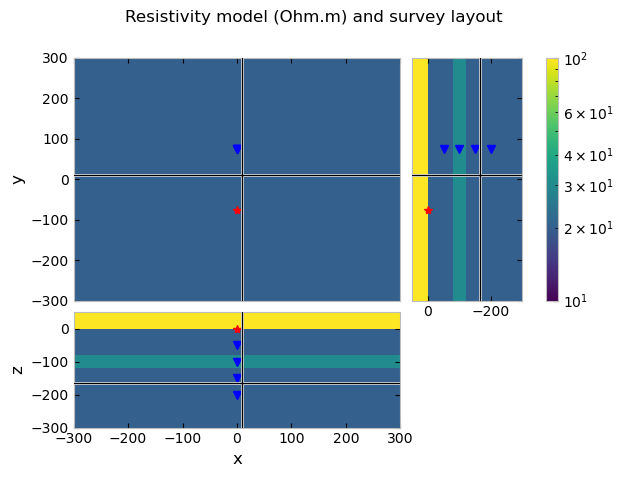

In [23]:
# Plot/QC the model
grid.plot_3d_slicer(
    model_base.property_x,
    pcolor_opts={'norm': LogNorm(vmin=10, vmax=100)},
    xlim=[-300, 300],
    ylim=[-300, 300],
    zlim=[-300, 50],
    zslice=-160,
)
# Plot survey in figure above
fig = plt.gcf()
fig.suptitle('Resistivity model (Ohm.m) and survey layout')
axs = fig.get_children()
rec_coords = [rec_x, rec_y, rec_z]
axs[1].plot(rec_coords[0], rec_coords[1], 'bv')
axs[2].plot(rec_coords[0], rec_coords[2], 'bv')
axs[3].plot(rec_coords[2], rec_coords[1], 'bv')
src_coords = [src_x, src_y, src_z]
axs[1].plot(src_coords[0], src_coords[1], 'r*')
axs[2].plot(src_coords[0], src_coords[2], 'r*')
axs[3].plot(src_coords[2], src_coords[1], 'r*')
axs[1].grid(False)
axs[2].grid(False)
axs[3].grid(False)

In [ ]:
#Use predefined function to insert a cuboid inton the target layer

x_extent = 150
y_extent = 150
zmin = depth[4]
zmax = depth[3]
res_QC = 13.1 #now: aquifer +50 °Celsius

res_QC = change_cuboid_resistivity(res_base.copy(), grid, x_extent, y_extent, zmin, zmax, res_QC)

model_QC = emg3d.Model(grid, property_x=res_QC, mapping='Resistivity')

In [ ]:
#QC cube location
grid.plot_3d_slicer(
    model_QC.property_x,
    pcolor_opts={'norm': LogNorm(vmin=1, vmax=100)},
    xlim=[-300, 300],
    ylim=[-300, 300],
    zlim=[-300, 50],
    zslice=-160,
)
fig = plt.gcf()

In [ ]:
#insert custom hot plume values [SKIP TO NEXT STEP IF RES FILE IS ALREADY SAVED]

#Load custom plume data
comsol_plume = np.loadtxt('test_plume_2.txt', skiprows=8) #data columns: radius, depth, temperature (K)

#crop data array to limit interpolation time
plume_crop = []
for i in np.arange(len(comsol_plume[:,0])):
    if comsol_plume[i,0] < 150 and comsol_plume[i,1] > depth[4] and comsol_plume[i,1] < depth[3]:
        plume_crop.append(comsol_plume[i])

ix_min, iy_min, iz_min, ix_max, iy_max, iz_max = find_cuboid_indeces_xyz(grid, x_extent, y_extent, zmin, zmax)

#interpolate temperature values and insert into 1d custom plume array
#To prevent edge effects, we assume that the min. temperature in the custom plume array is the original temperature of the aquifer before injection
rho_cold = resistivities_base[4]
T_cold = min(np.array(plume_crop)[:,2])
res_target3 = res_base.copy()
for ix in np.arange(ix_min, ix_max+1):
    for iy in np.arange(iy_min, iy_max+1):
        for iz in np.arange(iz_min, iz_max+1):
            loc = [grid.cell_centers_x[ix], grid.cell_centers_y[iy], grid.cell_centers_z[iz]] #select a cell coordinate from our grid
            radius = np.sqrt(loc[0]**2+loc[1]**2)
            loc2d = np.array([radius, loc[2]]) #flatten to 2d coordinates
            T_hot = plume_crop[interpolate2d(loc2d, plume_crop)][2] #find temperature value of COMSOL data point closest to this cell
            res_target3[ix, iy, iz] = rho_cold/(1+0.020*(T_hot-T_cold)) #translate to resistivity

#Save as new file in flattened form
np.savetxt('test_plume_2_interpolated.txt', res_target3.ravel('F'))

### Adjoint gradient simulations

#### Forward-modeling the measured data

In [24]:
#Create a survey design to generate measured data for each model (they are all the same, but have different names)

survey1 = emg3d.surveys.Survey(
    name='Survey 1',  # Name of the survey
    sources=src,               # Source coordinates
    receivers=rec,             # Receiver coordinates
    frequencies=frequencies,   # Two frequencies
    # data=data,               # Adding the observed data here will allow sensitivity calculation later, but we need to generate it first
    noise_floor=1e-15,
    relative_error=0.01,
)

In [26]:
#QC survey 1, should not contain data at this point
print(survey1)

:: Survey «Survey 1» ::

<xarray.Dataset> Size: 196B
Dimensions:   (src: 1, rec: 4, freq: 1)
Coordinates:
  * src       (src) <U6 24B 'TxED-1'
  * rec       (rec) <U6 96B 'RxEP-1' 'RxEP-2' 'RxEP-3' 'RxEP-4'
  * freq      (freq) <U3 12B 'f-1'
Data variables:
    observed  (src, rec, freq) complex128 64B (nan+nanj) ... (nan+nanj)
Attributes:
    noise_floor:     1e-15
    relative_error:  0.01


In [27]:
#The simulation class contains all that is needed to forward-model the measurement: survey, model, grid, and solving parameters

simulation1 = emg3d.simulations.Simulation(
        name='Simulation 1',    # A name for this simulation
        survey=survey1,        # Our survey instance
        model=model_base,          # The model
        gridding='same',      # Frequency- and source-dependent meshes
        max_workers=4,        # How many parallel jobs
        # solver_opts,        # Any parameter to pass to emg3d.solve
        #gridding_opts=gopts,  # Gridding options
        receiver_interpolation = "linear" #Needed for correct computation of the gradient
    )

simulation1.compute(observed=True)

Compute efields            0/1  [00:00]

##### Plots for QC of forward-models

In [28]:
#QC survey 1, should now contain data
print(survey1)

:: Survey «Survey 1» ::

<xarray.Dataset> Size: 260B
Dimensions:    (src: 1, rec: 4, freq: 1)
Coordinates:
  * src        (src) <U6 24B 'TxED-1'
  * rec        (rec) <U6 96B 'RxEP-1' 'RxEP-2' 'RxEP-3' 'RxEP-4'
  * freq       (freq) <U3 12B 'f-1'
Data variables:
    observed   (src, rec, freq) complex128 64B (-8.008193612971681e-07+9.1020...
    synthetic  (src, rec, freq) complex128 64B (-8.018461453767008e-07+1.1495...
Attributes:
    noise_floor:     1e-15
    relative_error:  0.01


(1e-10, 0.001)

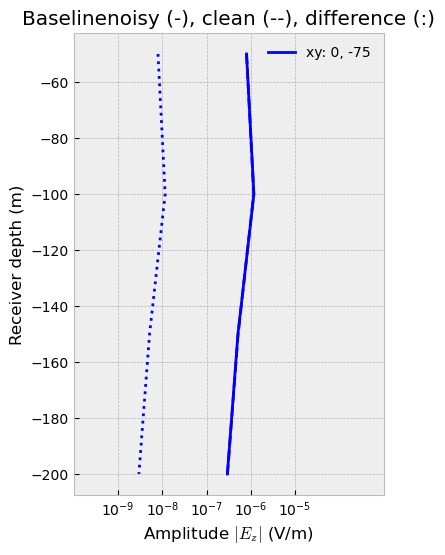

In [44]:
#QC receiver lines for all the sources

model_name = 'Baseline'
plt.figure(figsize=(4,6))
plt.title(''''''+model_name+'''noisy (-), clean (--), difference (:)''')
noisy = simulation1.data.observed[:, :, :]
clean = simulation1.data.synthetic[:, :, :]
noise = noisy - clean
for i, srcn in enumerate(simulation1.survey.sources):
    for ii, freq in enumerate(simulation1.survey.frequencies):
        plt.plot(np.abs(noisy.loc[srcn, :, freq].data),
                 rec_coords[2][:],
                color = colors[i],
                 label='xy: '+str(src_x)+', '+str(src_y) # else None
                 )
        plt.plot(np.abs(clean.loc[srcn, :, freq].data),
                 rec_coords[2][:],
                 '--',
                 color = colors[i],
                 )
        plt.plot(np.abs(noise.loc[srcn, :, freq].data),
         rec_coords[2][:],
         ':',
         color = colors[i],
         )
plt.xscale('log')
plt.legend(ncol=1, framealpha=0)
plt.ylabel('Receiver depth (m)')
plt.xlabel('Amplitude $|E_z|$ (V/m)')
ticks, labels = plt.xticks()
plt.xticks(ticks[1:-1])
plt.xlim([1e-10, 1e-3])

#The relative noise dominates and has amplitude of 1% of the data

#### Forward-modeling of the reference and gradient calculation

The survey we generated before now has observed data in it. We can continue with forward-modeling the reference (initial model) whilst this data (and the noise it contains) is encoded in the survey class.

In [32]:
#The simulation contains the measured data (through the survey) and the details needed to forward-model the reference

simulation2 = emg3d.simulations.Simulation(
    name='Simulation 2',    # A name for this simulation
    survey=survey1,        # Our survey instance
    model=model_base,      # The model
    gridding='same',      # Frequency- and source-dependent meshes
    max_workers=4,        # How many parallel jobs
    # solver_opts,        # Any parameter to pass to emg3d.solve
    #gridding_opts=gopts,  # Gridding options
    receiver_interpolation = "linear" # Needed for correct computation of the gradient
)

simulation2.compute()
gradient = simulation2.gradient
misfit = simulation2.misfit
gradient_flat = gradient.ravel('F')
max_gradient = max(gradient_flat)
rel_gradient = np.divide(gradient_flat,max_gradient)

Compute efields            0/1  [00:00]

Back-propagate            0/1  [00:00]

In [46]:
#QC survey 1, should now have the synthetic replaced by the reference model data and contain the meas data in observed
print(survey1)

:: Survey «Survey 1» ::

<xarray.Dataset> Size: 356B
Dimensions:    (src: 1, rec: 4, freq: 1)
Coordinates:
  * src        (src) <U6 24B 'TxED-1'
  * rec        (rec) <U6 96B 'RxEP-1' 'RxEP-2' 'RxEP-3' 'RxEP-4'
  * freq       (freq) <U3 12B 'f-1'
Data variables:
    observed   (src, rec, freq) complex128 64B (-8.008193612971681e-07+9.1020...
    synthetic  (src, rec, freq) complex128 64B (-8.018461453767008e-07+1.1495...
    weights    (src, rec, freq) float64 32B 1.559e+16 7.251e+15 ... 1.142e+17
    residual   (src, rec, freq) complex128 64B (-1.0267840795327249e-09-7.952...
Attributes:
    noise_floor:     1e-15
    relative_error:  0.01


##### Plots for QC of forward-models reference

(1e-10, 0.001)

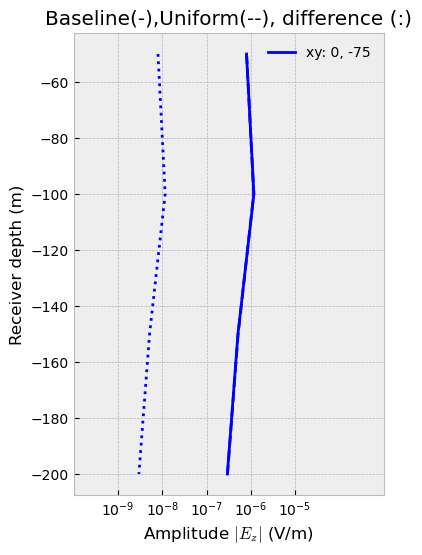

In [47]:
#QC receiver lines for all the sources

model_name = 'Baseline'
ref_name = 'Uniform'
plt.figure(figsize=(4,6))
plt.title(''''''+model_name+'''(-),'''+ref_name+'''(--), difference (:)''')
noisy = simulation1.data.observed[:, :, :]
clean = simulation1.data.synthetic[:, :, :]
noise = noisy - clean
for i, srcn in enumerate(simulation1.survey.sources):
    for ii, freq in enumerate(simulation1.survey.frequencies):
        plt.plot(np.abs(noisy.loc[srcn, :, freq].data),
                 rec_coords[2][:],
                color = colors[i],
                 label='xy: '+str(src_x)+', '+str(src_y) # else None
                 )
        plt.plot(np.abs(clean.loc[srcn, :, freq].data),
                 rec_coords[2][:],
                 '--',
                 color = colors[i],
                 )
        plt.plot(np.abs(noise.loc[srcn, :, freq].data),
         rec_coords[2][:],
         ':',
         color = colors[i],
         )
plt.xscale('log')
plt.legend(ncol=1, framealpha=0)
plt.ylabel('Receiver depth (m)')
plt.xlabel('Amplitude $|E_z|$ (V/m)')
ticks, labels = plt.xticks()
plt.xticks(ticks[1:-1])
plt.xlim([1e-10, 1e-3])

#The relative noise dominates and has amplitude of 1% of the data

#### Adjoint gradient results

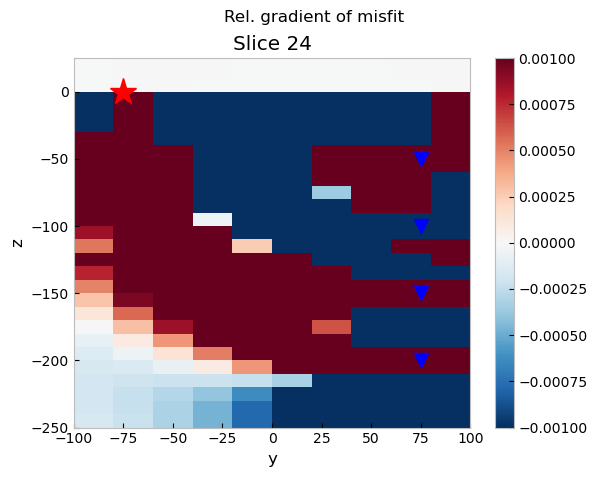

In [71]:
#Focus on the y,z plane

#Plot the simulated electric field
f0 = grid.plot_slice(
    gradient_flat,
    pcolor_opts={'cmap': 'RdBu_r',
             'norm': Normalize(vmin=-1e-3, vmax=1e-3)},
    normal = 'X',
    range_x=[-100, 100], #y extent
    range_y=[-250, 25], #z extent
    slice_loc=0 #, defaults to 0
)
fig = plt.gcf()
fig.suptitle('Rel. gradient of misfit')
axs = fig.get_children()
axs[1].grid(False)
rec_coords = survey1.receiver_coordinates()
src_coords = survey1.source_coordinates()
axs[1].plot(rec_coords[1], rec_coords[2], 'bv', markersize = 10)
axs[1].plot(src_coords[1], src_coords[2], 'r*', markersize = 20)
fig.colorbar(f0[0], ax = axs[1])

### Finite difference gradient simulations

In [56]:
# Define epsilon (some small resistivity value, Ohmm).
epsilon = 0.01

# Define the cross-section.
ix = grid.shape_cells[1]//2

def comp_fd_grad(iyiz):
    """Compute forward-FD gradient for one cell."""

    # Copy the computational model.
    fd_model = model_base.copy()

    # Add conductivity-epsilon to this (ix, iy, iz) cell.
    fd_model.property_x[ix, iyiz[0], iyiz[1]] += epsilon

    # Create a new simulation with this model
    simulation_fd = emg3d.simulations.Simulation(
        name='FD Gradient Test',
        survey=survey1, 
        model=fd_model,
        gridding='same',
        max_workers=1,
        solver_opts={'verb': 1},
        receiver_interpolation='linear',  # For proper adjoint-state gradient
    )

    # Switch-of progress bar in this case
    simulation_fd._tqdm_opts['disable'] = True

    # Get misfit
    fd_data_misfit = simulation_fd.misfit

    # Return gradient
    return float((fd_data_misfit - misfit)/epsilon)

In [57]:
import itertools

In [58]:
#grid precise results domain: [-50, 50], [-100, 100], [-250, 0]

In [59]:
# Initiate FD gradient.
fd_grad = np.zeros_like(gradient)

# Get all ix-iz combinations (without air/water).
iyiz = list(itertools.product(
    range(grid.shape_cells[1]),
    range(len(grid.cell_centers_z[grid.cell_centers_z < 0])))
)

mm = simulation1.model.grid
for i, (iy, iz) in enumerate(iyiz):
    if mm.nodes_y[iy] < -100 or mm.nodes_y[iy] > 100:
        continue
    if mm.nodes_z[iz] < -250 or mm.nodes_z[iz] > 0:
        continue
    fd_grad[ix, iy, iz] = comp_fd_grad([iy, iz])

#### FD gradient results

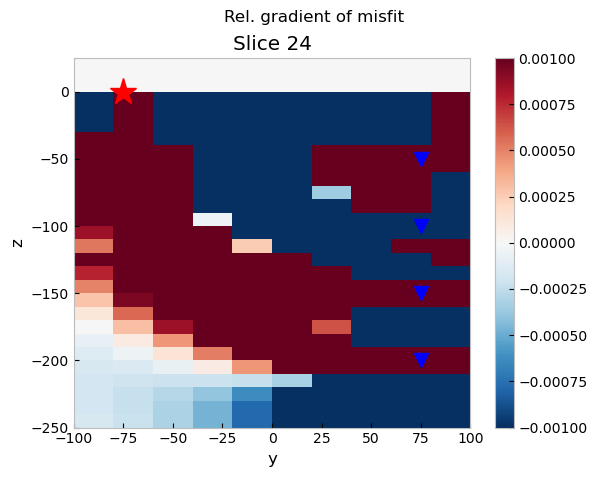

In [69]:
#Focus on the y,z plane

#Plot the simulated electric field
f0 = grid.plot_slice(
    fd_grad,
    pcolor_opts={'cmap': 'RdBu_r',
             'norm': Normalize(vmin=-1e-3, vmax=1e-3)},
    normal = 'X',
    range_x=[-100, 100], #y extent
    range_y=[-250, 25], #z extent
    slice_loc=0 #, defaults to 0
)
fig = plt.gcf()
fig.suptitle('Rel. gradient of misfit')
axs = fig.get_children()
axs[1].grid(False)
rec_coords = survey1.receiver_coordinates()
src_coords = survey1.source_coordinates()
axs[1].plot(rec_coords[1], rec_coords[2], 'bv', markersize = 10)
axs[1].plot(src_coords[1], src_coords[2], 'r*', markersize = 20)
fig.colorbar(f0[0], ax = axs[1])

In [72]:
from matplotlib.colors import LogNorm, SymLogNorm
from matplotlib.patches import Rectangle

0.7209749657448583
0.0


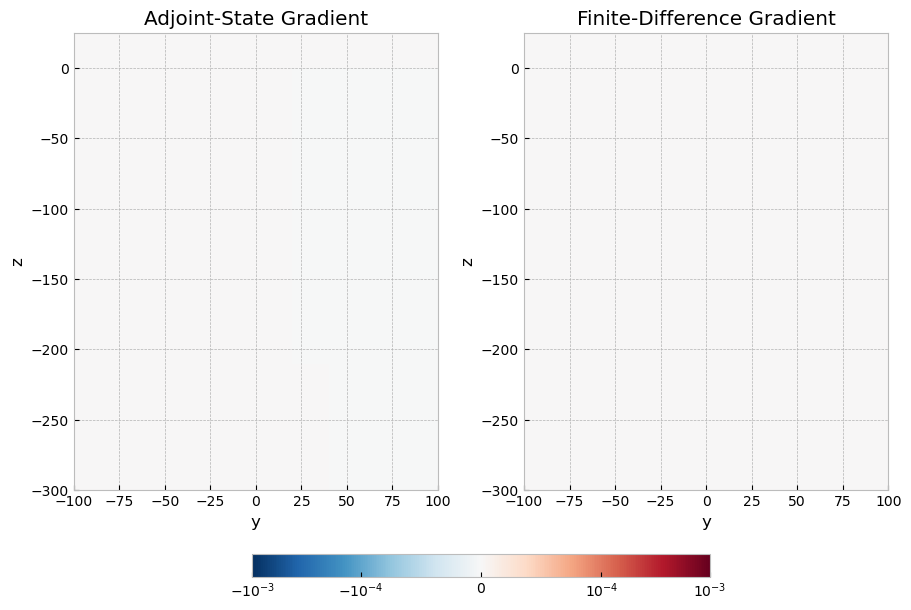

In [78]:
# Compute NRMSD between AS and FD (%).
nrmsd = 200*abs(gradient-fd_grad)/(abs(gradient)+abs(fd_grad))
nrmsd[fd_grad == 0] = np.nan

# Compute sign.
tiny = np.finfo(float).tiny  # Avoid division by zero.
diff_sign = np.sign(gradient/np.where(abs(fd_grad) < tiny, tiny, fd_grad))
    
    
def plot_diff(ax, diff):
    """Helper routine to show cells of big NRMSD or different sign."""

    for iy in range(grid.h[1].size):
        for iz in range(grid.h[2].size):

            if diff_sign[ix, iy, iz] < 0:
                ax.add_patch(
                        Rectangle(
                            (grid.nodes_y[iy], grid.nodes_z[iz]),
                            grid.h[1][iy], grid.h[2][iz], fill=False,
                            color='k', lw=1))

            if nrmsd[ix, iy, iz] >= diff:
                ax.add_patch(
                        Rectangle(
                            (grid.nodes_y[iy], grid.nodes_z[iz]),
                            grid.h[1][iy], grid.h[2][iz], fill=False,
                            color='m', linestyle='--', lw=0.5))


def set_axis(axs, i):
    """Helper routine to adjust subplots."""

    # Show source and receiver.
    axs[i].plot(rec_coords[1], rec_coords[2], 'bv')
    axs[i].plot(src_coords[1], src_coords[2], 'r*')

    # x-label.
    axs[i].set_xlabel('Easting')

    # y-label depending on column.
    if i == 0:
        axs[i].set_ylabel('Depth')
    else:
        axs[i].set_ylabel('')
        axs[i].axes.yaxis.set_ticklabels([])
    
    # Set limits.
    axs[i].set_xlim(-3000, 3000)
    axs[i].set_ylim(-4000, -1900)


# Plotting options.
vmin, vmax = 1e-4, 1e-3
pcolor_opts = {'cmap': 'RdBu_r',
               'norm': SymLogNorm(linthresh=vmin, base=10,
                                  vmin=-vmax, vmax=vmax)}

fig, axs = plt.subplots(
        figsize=(9, 6), nrows=1, ncols=2, constrained_layout=True)

# Adjoint-State Gradient
f0 = grid.plot_slice(gradient_flat, normal='X', ind=iy, ax=axs[0],
                          pcolor_opts=pcolor_opts, range_x=[-100, 100], range_y=[-300, 25])
axs[0].set_title("Adjoint-State Gradient")
#set_axis(axs, 0)
#plot_diff(axs[0], 1)

max_fd_grad = np.max(fd_grad)
print(max_fd_grad)
print(fd_grad[15, 15, 15])

# Finite-Difference Gradient
f1 = grid.plot_slice(fd_grad, normal='X', ind=iy, ax=axs[1],
                          pcolor_opts=pcolor_opts, range_x=[-100, 100], range_y=[-300, 25])
axs[1].set_title("Finite-Difference Gradient")
#set_axis(axs, 1)
#plot_diff(axs[1], 1)

fig.colorbar(f0[0], ax=axs, orientation='horizontal', fraction=0.05)

## Comparing empymod gradient and also the FD version

In [62]:
#Create a survey design to generate measured data for each model (they are all the same, but have different names)

survey1e = emg3d.surveys.Survey(
    name='Survey 1e',  # Name of the survey
    sources=src,               # Source coordinates
    receivers=rec,             # Receiver coordinates
    frequencies=frequencies,   # Two frequencies
    # data=data,               # Adding the observed data here will allow sensitivity calculation later, but we need to generate it first
    noise_floor=1e-15,
    relative_error=0.01,
)

In [63]:
#The simulation class contains all that is needed to forward-model the measurement: survey, model, grid, and solving parameters

simulation1e = emg3d.simulations.Simulation(
        name='Simulation 1e',    # A name for this simulation
        survey=survey1e,        # Our survey instance
        model=model_base,          # The model,
        max_workers=4,        # How many parallel jobs
        layered=True,
        receiver_interpolation = "linear" #Needed for correct computation of the gradient
    )

simulation1.compute(observed=True)

Compute efields            0/1  [00:00]

In [64]:
simulation2e = emg3d.simulations.Simulation(
    name='Simulation 2e',    # A name for this simulation
    survey=survey1e,        # Our survey instance
    model=model_base,      # The model
    max_workers=4,        # How many parallel jobs
    layered=True,
)

gradient_emp = simulation2e.gradient

Compute empymod            0/1  [00:00]

Compute empymod            0/1  [00:00]

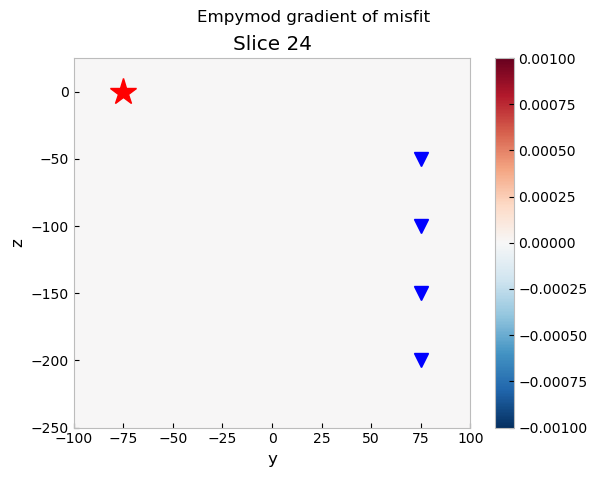

In [80]:
#Focus on the y,z plane

#Plot the simulated electric field
f0 = grid.plot_slice(
    gradient_emp,
    pcolor_opts={'cmap': 'RdBu_r',
             'norm': Normalize(vmin=-1e-3, vmax=1e-3)},
    normal = 'X',
    range_x=[-100, 100], #y extent
    range_y=[-250, 25], #z extent
    slice_loc=0 #, defaults to 0
)
fig = plt.gcf()
fig.suptitle('Empymod gradient of misfit')
axs = fig.get_children()
axs[1].grid(False)
rec_coords = survey1.receiver_coordinates()
src_coords = survey1.source_coordinates()
axs[1].plot(rec_coords[1], rec_coords[2], 'bv', markersize = 10)
axs[1].plot(src_coords[1], src_coords[2], 'r*', markersize = 20)
fig.colorbar(f0[0], ax = axs[1])

In [ ]:
emg3d.Report()